# **BASE CODE — Grover (single iteration)**

In [1]:
!pip install qiskit qiskit-aer matplotlib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.9 MB/s eta 0:00:00


In [2]:
!pip install qiskit qiskit-aer

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt
import numpy as np

# ✅ Guaranteed working histogram (never blank)
def plot_counts(counts, title="Histogram"):
    labels = sorted(counts.keys())
    values = [counts[k] for k in labels]

    plt.figure(figsize=(6,4))
    plt.bar(range(len(labels)), values)
    plt.xticks(range(len(labels)), labels)
    plt.xlabel("Measured Output")
    plt.ylabel("Counts")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()


In [3]:
def oracle(qc, n, marked_state):
    for i, bit in enumerate(marked_state):
        if bit == "0":
            qc.x(i)

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    for i, bit in enumerate(marked_state):
        if bit == "0":
            qc.x(i)


def diffuser(qc, n):
    qc.h(range(n))
    qc.x(range(n))

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    qc.x(range(n))
    qc.h(range(n))


In [4]:
def run(qc, shots=1024, title="Result"):
    sim = AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots).result()
    counts = result.get_counts()
    plot_counts(counts, title)
    print("Counts:", counts)


     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐      
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├──────
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤     └╥┘┌─┐   
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────╫─┤M├───
     ├───┤├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ║ └╥┘┌─┐
q_2: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫──╫─┤M├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║  ║ └╥┘
c: 3/════════════════════════════════════════════════════════╩══╩══╩═
                                                             0  1  2 


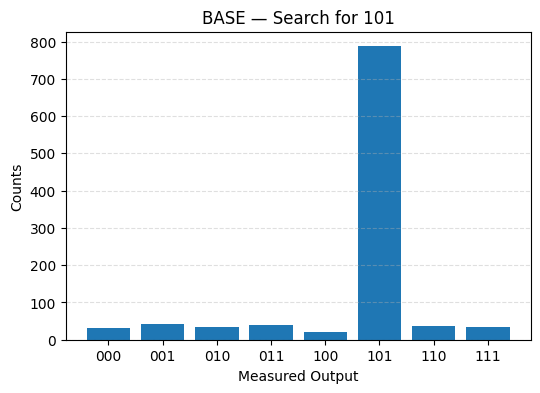

Counts: {'110': 36, '001': 42, '100': 22, '000': 31, '010': 33, '011': 40, '111': 33, '101': 787}


In [5]:
def grover_3qubit(marked_state="101"):
    n = len(marked_state)
    qc = QuantumCircuit(n, n)

    qc.h(range(n))  # initialization
    oracle(qc, n, marked_state)
    diffuser(qc, n)
    qc.measure(range(n), range(n))
    return qc

qc = grover_3qubit("101")
print(qc.draw())
run(qc, title="BASE — Search for 101")


# **TASK 1: Change Marked State**




Searching for: 111


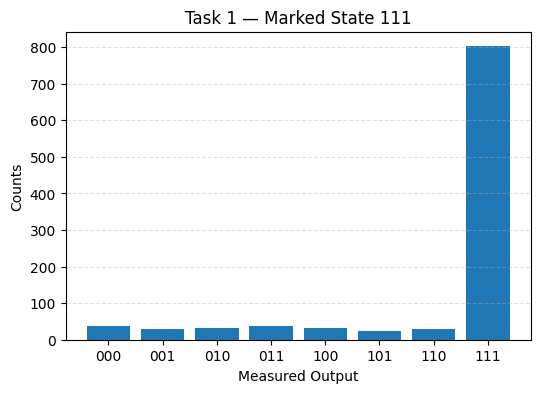

Counts: {'101': 23, '001': 30, '110': 28, '010': 32, '000': 38, '100': 33, '111': 802, '011': 38}

Searching for: 010


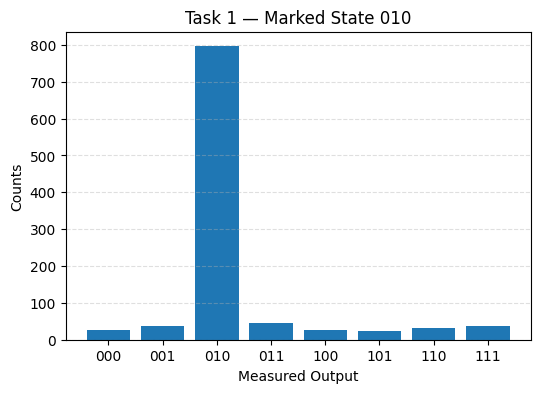

Counts: {'001': 37, '101': 24, '110': 31, '100': 27, '011': 46, '111': 37, '000': 26, '010': 796}


In [6]:
for state in ["111", "010"]:
    print("\nSearching for:", state)
    qc = grover_3qubit(state)
    run(qc, title=f"Task 1 — Marked State {state}")


# **Task 2: TASK 2: Extend to 4 Qubits**

     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐         
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├─────────
     ├───┤       │  ├───┤├───┤            │  ├───┤├───┤     └╥┘┌─┐      
q_1: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────╫─┤M├──────
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤      ║ └╥┘┌─┐   
q_2: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────╫──╫─┤M├───
     ├───┤├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ║  ║ └╥┘┌─┐
q_3: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫──╫──╫─┤M├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║  ║  ║ └╥┘
c: 4/════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                             0  1  2  3 


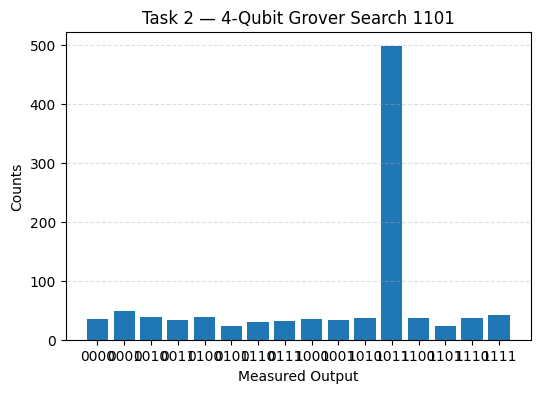

Counts: {'0001': 49, '0111': 32, '0011': 33, '1011': 498, '1110': 37, '1001': 33, '0101': 24, '0010': 38, '0000': 35, '1101': 24, '0100': 39, '1100': 37, '0110': 30, '1000': 36, '1010': 37, '1111': 42}


In [7]:
def grover_4qubit(marked_state="1101"):
    n = len(marked_state)
    qc = QuantumCircuit(n, n)

    qc.h(range(n))
    oracle(qc, n, marked_state)
    diffuser(qc, n)
    qc.measure(range(n), range(n))
    return qc

qc = grover_4qubit("1101")
print(qc.draw())
run(qc, title="Task 2 — 4-Qubit Grover Search 1101")


# **TASK 3: Multiple Grover Iterations (for stronger probability)**

     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐               ┌───┐»
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├»
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤┌───┐       │  ├───┤»
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├»
     ├───┤├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤»
q_2: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
c: 3/══════════════════════════════════════════════════════════════════════»
                                                                           »
«     ┌───┐               ┌───┐┌───┐               ┌───┐┌───┐               »
«q_0: ┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├┤ X ├────────────■──»
«     ├───┤┌───┐       │  ├───┤├───┤┌───┐       │  ├───┤├───┤┌───┐       │  »
«q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────

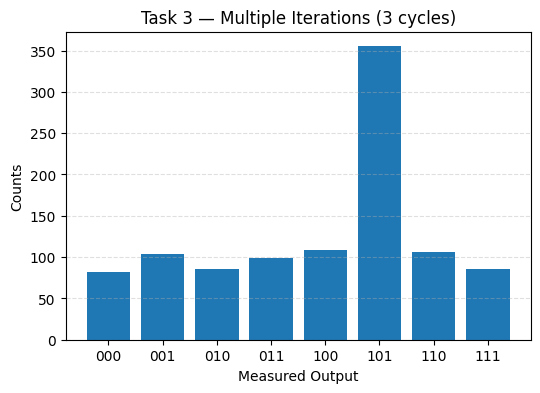

Counts: {'110': 106, '100': 108, '101': 355, '011': 99, '111': 85, '000': 82, '010': 85, '001': 104}


In [8]:
def grover_iterations(marked_state="101", iterations=2):
    n = len(marked_state)
    qc = QuantumCircuit(n, n)

    qc.h(range(n))

    for _ in range(iterations):
        oracle(qc, n, marked_state)
        diffuser(qc, n)

    qc.measure(range(n), range(n))
    return qc

qc = grover_iterations("101", iterations=3)
print(qc.draw())
run(qc, title="Task 3 — Multiple Iterations (3 cycles)")


# **Task 4: Circuit Visualization (mpl)**

In [9]:
!pip install pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9c061cb0e4cfd2c9cce4d1925ee74aee6e21aaeba2b3df6c3106de6c550fac5f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [10]:
from qiskit.visualization import matplotlib

qc = grover_3qubit("101")

# ✅ Force Matplotlib drawer
fig = qc.draw(output='mpl')
plt.show()
print(qc.draw(fold=-1))



     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐     ┌─┐      
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────┤M├──────
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤     └╥┘┌─┐   
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────╫─┤M├───
     ├───┤├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ║ └╥┘┌─┐
q_2: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫──╫─┤M├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║  ║ └╥┘
c: 3/════════════════════════════════════════════════════════╩══╩══╩═
                                                             0  1  2 


# **Task 5: Add Noise (Aer NoiseModel)**

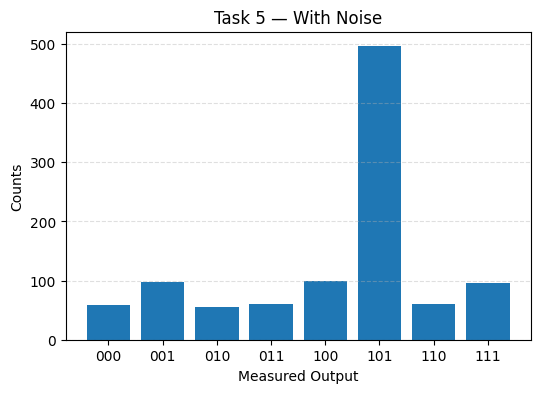

Counts: {'110': 60, '100': 100, '011': 61, '111': 96, '000': 59, '010': 55, '001': 97, '101': 496}


In [14]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

def run_with_noise(qc):
    noise = NoiseModel()
    noise.add_all_qubit_quantum_error(depolarizing_error(0.05, 1), ['h','x'])
    noise.add_all_qubit_quantum_error(depolarizing_error(0.10, 2), ['mcx'])

    sim = AerSimulator(noise_model=noise)
    tqc = transpile(qc, sim)

    result = sim.run(tqc, shots=1024).result()
    counts = result.get_counts()

    plot_counts(counts, "Task 5 — With Noise")
    print("Counts:", counts)

qc = grover_3qubit("101")
run_with_noise(qc)
